In [64]:
from getdist import loadMCSamples
import getdist.plots as plots
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [65]:
# Set Main Chain Dictionary
chains = {}
models = {}
chain_dir = Path(r'/home/theppawan/cosmo-research/quintom-project/chains')
chain_prefixes = [p.with_suffix('') for p in chain_dir.rglob('*.checkpoint')]

for prefix_path in chain_prefixes:
    chain_name = prefix_path.name
    model, dataset = chain_name.split("_", 1)

    # Set model label
    if 'lcdm' in model:
        models_label = r'\Lambda {\rm CDM}'
    else:
        models_label = model.capitalize()
    models[model] = models_label

    # Set dataset label
    if 'theta' in dataset:
        label = dataset.replace("theta", r"$\theta_*$")
    else:
        label = dataset
    chains[chain_name] = [loadMCSamples(str(prefix_path)), rf"{label}", models_label]

In [66]:
plt.rcParams['text.usetex'] = False 
plt.rcParams['mathtext.fontset'] = 'cm' 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']

### Posterior contours in $\Omega_M$ and $H_0r_d$ on $\Lambda {\rm CDM}$ model with:
- DESI
- CMB

In [59]:
post_process_path = {'CMB': [chain_dir / 'lcdm/CMB/lcdm_CMB.post.add_H0rd', 'CMB'], 
                     'DESI': [chain_dir / 'lcdm/DESI/lcdm_DESI.post.add_H0rd', 'DESI']}
post_process_samples = {key: [loadMCSamples(str(path)), label] for key, [path, label] in post_process_path.items()}

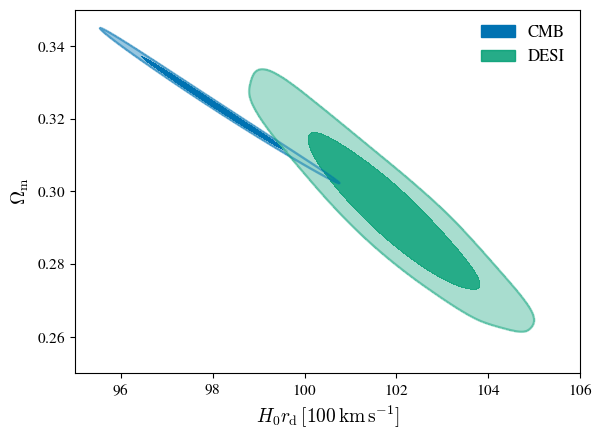

In [60]:
# Setting up the plot
plot_settings = plots.GetDistPlotSettings()
plot_settings.legend_frame = False  # Removes the box around the legend
plot_settings.alpha_filled_add = 0.85      # Adjust transparency of filled contours

g = plots.get_single_plotter(settings=plot_settings)

# plot_2d function
g.plot_2d([post_process_samples['CMB'][0], post_process_samples['DESI'][0]],
          'H0rd',
          'Omega_m',
          filled=True,
          colors=["#0072B2", "#009E73"],
          lws=1
         )

# Explicitly add the legend here
labels = [post_process_samples['CMB'][1], post_process_samples['DESI'][1]]
g.add_legend(labels, legend_loc='upper right', legend_ncol=1) # You can adjust the location

plt.xlim(95, 106)
plt.ylim(0.25, 0.35)
plt.show()
g.export(f'figure/lcdm_2d_posterior_H0rd.pdf')

### Posterior contours in $\Omega_M$ and $H_0$ on $\Lambda {\rm CDM}$ model with:
- DESI+BBN
- DESI+BBN+$\theta_*$
- CMB

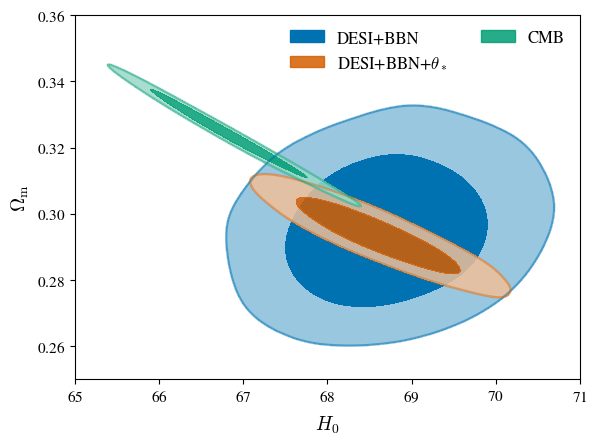

In [61]:
# Setting up the plot
plot_settings = plots.GetDistPlotSettings()
plot_settings.legend_frame = False  # Removes the box around the legend
plot_settings.alpha_filled_add = 0.85      # Adjust transparency of filled contours

g = plots.get_single_plotter(settings=plot_settings)

# plot_2d function
g.plot_2d([chains['lcdm_DESI+BBN'][0], chains['lcdm_DESI+BBN+theta'][0], chains['lcdm_CMB'][0]],
          'H0',
          'Omega_m',
          filled=True,
          colors=["#0072B2", "#D55E00", "#009E73"],
          lws=1
         )

# Explicitly add the legend here
labels = [chains['lcdm_DESI+BBN'][1], chains['lcdm_DESI+BBN+theta'][1], chains['lcdm_CMB'][1]]
g.add_legend(labels, legend_loc='upper right', legend_ncol=2) # You can adjust the location

plt.xlim(65, 71)
plt.ylim(0.25, 0.36)
plt.show()
g.export(f'figure/lcdm_2d_posterior.pdf')

### Posterior Distributions of $\lambda_{\rm qtm}$ and $\delta_{\rm qtm}$, from fits of the Quintom Model to
- DESI+CMB+SNIa
- DESI+CMB

In [67]:
for [sample, _, _] in chains.values():
    p = sample.getParams()
    try:
        abs_delta_qtm = np.abs(p.delta_qtm)
        sample.addDerived(abs_delta_qtm, name='abs_delta_qtm', label=r'|\delta_{\mathrm{qtm}}|')
    except AttributeError:
        print(f"Parameter 'delta_qtm' not found in sample: {sample.getName()}")
        continue

Parameter 'delta_qtm' not found in sample: lcdm_CMB
Parameter 'delta_qtm' not found in sample: lcdm_DESI
Parameter 'delta_qtm' not found in sample: lcdm_DESI+BBN+theta
Parameter 'delta_qtm' not found in sample: lcdm_DESI+BBN
Parameter 'delta_qtm' not found in sample: lcdm_DESI+CMB


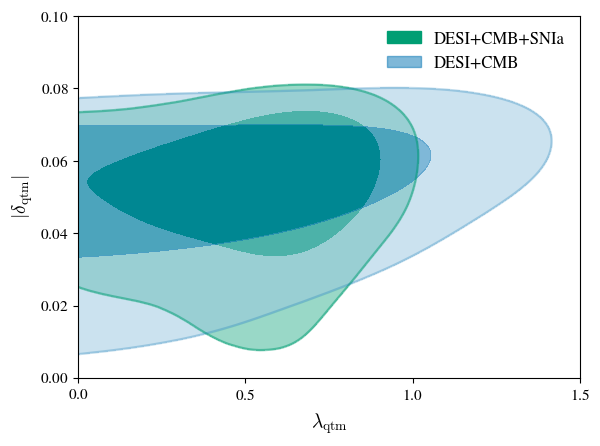

In [68]:
# Setting up the plot
plot_settings = plots.GetDistPlotSettings()
plot_settings.legend_frame = False  # Removes the box around the legend
plot_settings.alpha_filled_add = 0.50      # Adjust transparency of filled contours

g = plots.get_single_plotter(settings=plot_settings)

# plot_2d function
g.plot_2d([chains['quintom_DESI+CMB+SNIa'][0], chains['quintom_DESI+CMB'][0]],
          'lambda_qtm',
          'abs_delta_qtm',
          filled=True,
          colors=["#009E73","#0072B2"],
          lws=1
         )

# Explicitly add the legend here
labels = [chains['quintom_DESI+CMB+SNIa'][1], chains['quintom_DESI+CMB'][1]]
g.add_legend(labels, legend_loc='upper right', legend_ncol=1) # You can adjust the location

plt.xlim(0, 1.5)
plt.ylim(0, 0.1)
plt.show()
g.export(f'figure/quintom_2d_posterior_DE_params.pdf')

### Posterior Distribution comparing between $\Lambda {\rm CDM}$ and Quintom Model with:
- DESI+BBN
- DESI+CMB
- DESI

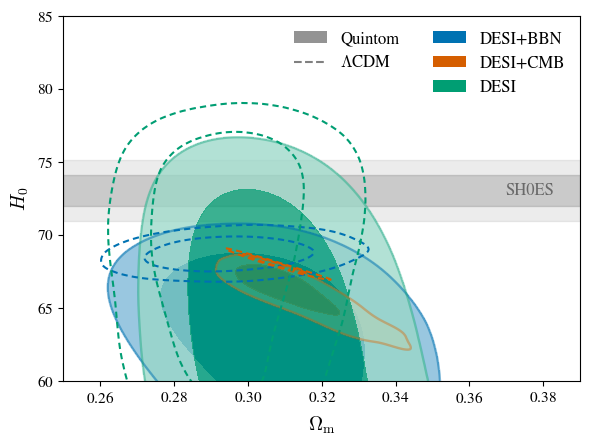

In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms

# Setting up the plot
plot_settings = plots.GetDistPlotSettings()
plot_settings.legend_frame = False      # Removes the box around the legend
plot_settings.alpha_filled_add = 0.75   # Adjust transparency of filled contours

g = plots.get_single_plotter(settings=plot_settings)

# True for Quintom (filled), False for LCDM (lines only)
fill_styles = [True, True, True, False, False, False]
contour_colors = ['#0072B2', '#D55E00', '#009E73', '#0072B2', '#D55E00', '#009E73']
line_widths = [1, 1, 1, 1.5, 1.5, 1.5]
line_styles = ['-', '-', '-', '--', '--', '--'] 

# plot_2d function
g.plot_2d([chains['quintom_DESI+BBN'][0], 
           chains['quintom_DESI+CMB'][0],
           chains['quintom_DESI'][0],
           chains['lcdm_DESI+BBN'][0], 
           chains['lcdm_DESI+CMB'][0],
           chains['lcdm_DESI'][0]],
          'Omega_m',
          'H0',
          filled=fill_styles,
          colors=contour_colors,
          lws=line_widths,
          ls=line_styles
         )

# --- ADD SH0ES BAND ---
ax = plt.gca() # Get current matplotlib axis

# SH0ES 2022 H0 values (Riess et al. 2022)
h0_mean = 73.04
h0_sigma = 1.04

# Add 1-sigma and 2-sigma horizontal bands
# zorder=0 ensures the bands stay securely behind the posterior contours
ax.axhspan(h0_mean - h0_sigma, h0_mean + h0_sigma, color='gray', alpha=0.3, zorder=0)
ax.axhspan(h0_mean - 2*h0_sigma, h0_mean + 2*h0_sigma, color='gray', alpha=0.15, zorder=0)
# ax.axhline(h0_mean, color='gray', ls='--', lw=1.5, zorder=0)

# Optional: Add a text label directly on the plot for SH0ES 
# (This often looks cleaner than stuffing it into a crowded chain legend)
trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
ax.text(0.95, h0_mean, 'SH0ES', transform=trans, color='dimgray', 
        ha='right', va='center', fontsize=12, zorder=0)

# ----------------------

# Explicitly add the legend here
# Define Dataset Colors (Using full opacity patches for a clean look)

style_quintom = Patch(facecolor='gray', alpha=0.85, label='Quintom')
style_lcdm = Line2D([0], [0], color='gray', lw=1.5, ls='--', label=r'$\Lambda$CDM')
blank_spacer = Patch(color='none', label='')    # Invisible spacer for alignment
color_bbn = Patch(facecolor='#0072B2', label='DESI+BBN')
color_cmb = Patch(facecolor='#D55E00', label='DESI+CMB')
color_desi = Patch(facecolor='#009E73', label='DESI')

# Add the legend
custom_handles = [style_quintom, style_lcdm, blank_spacer, color_bbn, color_cmb, color_desi]
ax.legend(handles=custom_handles, loc='upper right', frameon=False, ncol=2, fontsize=12)

# --------------------------------

plt.xlim(0.25, 0.39)
plt.ylim(60, 85)
plt.show()
g.export('figure/lcdm_quintom_2d_posterior.pdf')